# 01 — Exploratory Data Analysis & DataLoader Verification
**Track 2B: Thyroid Nodule Ultrasound Segmentation (TN3k)**
**Branch:** `feature/baseline-and-dataloader`

This notebook provides an interactive exploratory analysis of the TN3k dataset:
1. Environment & reproducibility seed verification
2. Global and per-mask pixel imbalance statistics
3. Nodule area distribution histogram
4. Visual overlay grid (2x4) of raw ultrasound images and ground-truth masks
5. PyTorch `TN3kDataset` & `DataLoader` batch verification


In [1]:
import os
import sys
from pathlib import Path

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.utils import seed_everything, get_device
from src.eda import calculate_pixel_imbalance, get_nodule_size_distribution
from src.dataset import TN3kDataset, get_loaders

seed = seed_everything(42)
device = get_device()

data_root = PROJECT_ROOT / "data" / "tn3k"
trainval_img_dir = data_root / "trainval-image"
trainval_mask_dir = data_root / "trainval-mask"
test_img_dir = data_root / "test-image"
test_mask_dir = data_root / "test-mask"

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")
print(f"Reproducibility seed: {seed}")
print(f"Trainval Images: {len(list(trainval_img_dir.glob('*.jpg')))}")
print(f"Trainval Masks:  {len(list(trainval_mask_dir.glob('*.jpg')))}")
print(f"Test Images:     {len(list(test_img_dir.glob('*.jpg')))}")
print(f"Test Masks:      {len(list(test_mask_dir.glob('*.jpg')))}")


[INFO] Using device: cpu
Project root: D:\DL Hackathon\thyroid-ultrasound-segmentation
Device: cpu
Reproducibility seed: None
Trainval Images: 2879
Trainval Masks:  2879
Test Images:     614
Test Masks:      614


In [2]:
from IPython.display import display, Markdown

mask_dir = str(trainval_mask_dir)
imbalance_stats = calculate_pixel_imbalance(mask_dir)

mean_fg = imbalance_stats["mean_fg_ratio"]
median_fg = imbalance_stats["median_fg_ratio"]
min_fg = imbalance_stats["min_fg_ratio"]
max_fg = imbalance_stats["max_fg_ratio"]
std_fg = imbalance_stats["std_fg_ratio"]
global_fg = imbalance_stats["global_fg_ratio"]
global_bg = imbalance_stats["global_bg_ratio"]

markdown_table = f"""
### TN3k Dataset Class Imbalance Statistics (Trainval Set, $N=2,879$)

| Metric | Value (Ratio) | Value (Percentage) |
| :--- | :--- | :--- |
| **Mean Foreground (Nodule) Ratio** | `{mean_fg:.4f}` | **{mean_fg * 100:.2f}%** |
| **Median Foreground (Nodule) Ratio** | `{median_fg:.4f}` | **{median_fg * 100:.2f}%** |
| **Min Foreground (Nodule) Ratio** | `{min_fg:.4f}` | **{min_fg * 100:.2f}%** |
| **Max Foreground (Nodule) Ratio** | `{max_fg:.4f}` | **{max_fg * 100:.2f}%** |
| **Standard Deviation** | `{std_fg:.4f}` | **{std_fg * 100:.2f}%** |
| **Global Foreground Ratio** | `{global_fg:.4f}` | **{global_fg * 100:.2f}%** |
| **Global Background Ratio** | `{global_bg:.4f}` | **{global_bg * 100:.2f}%** |
"""

display(Markdown(markdown_table))



### TN3k Dataset Class Imbalance Statistics (Trainval Set, $N=2,879$)

| Metric | Value (Ratio) | Value (Percentage) |
| :--- | :--- | :--- |
| **Mean Foreground (Nodule) Ratio** | `0.1422` | **14.22%** |
| **Median Foreground (Nodule) Ratio** | `0.0857` | **8.57%** |
| **Min Foreground (Nodule) Ratio** | `0.0020` | **0.20%** |
| **Max Foreground (Nodule) Ratio** | `0.7588` | **75.88%** |
| **Standard Deviation** | `0.1433` | **14.33%** |
| **Global Foreground Ratio** | `0.1273` | **12.73%** |
| **Global Background Ratio** | `0.8727` | **87.27%** |


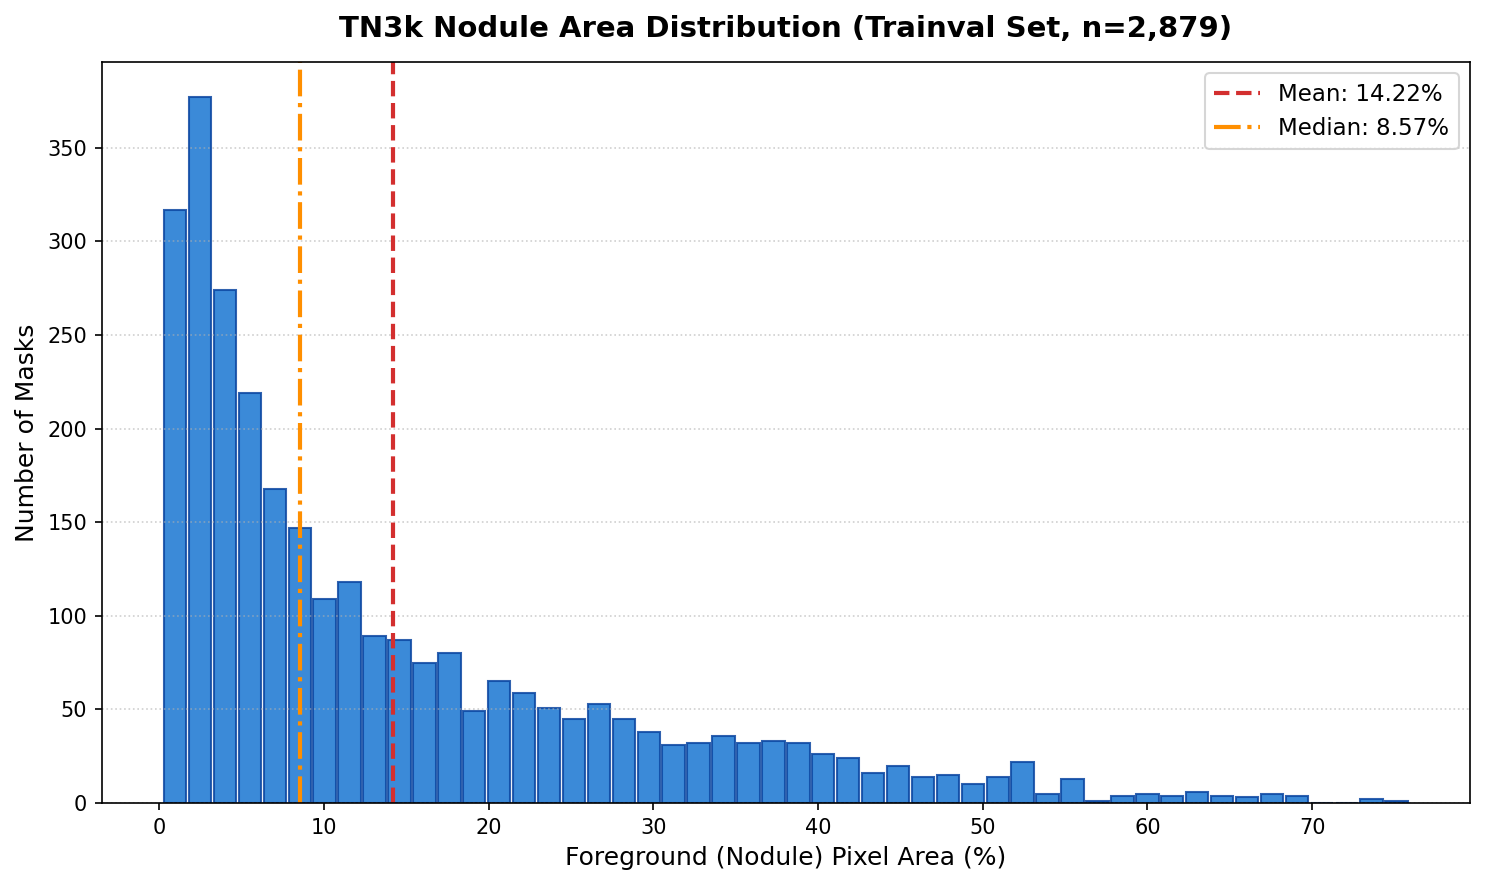

Saved nodule area distribution histogram to: D:\DL Hackathon\thyroid-ultrasound-segmentation\outputs\eda_class_imbalance.png


In [3]:
output_dir = PROJECT_ROOT / "outputs"
output_dir.mkdir(exist_ok=True, parents=True)
hist_path = output_dir / "eda_class_imbalance.png"

per_mask_ratios = imbalance_stats["per_mask_ratios"] * 100

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.hist(per_mask_ratios, bins=50, color="#1976D2", edgecolor="#0D47A1", alpha=0.85, rwidth=0.9)
ax.axvline(mean_fg * 100, color="#D32F2F", linestyle="--", linewidth=2, label=f"Mean: {mean_fg * 100:.2f}%")
ax.axvline(median_fg * 100, color="#FF8F00", linestyle="-.", linewidth=2, label=f"Median: {median_fg * 100:.2f}%")

ax.set_title("TN3k Nodule Area Distribution (Trainval Set, n=2,879)", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Foreground (Nodule) Pixel Area (%)", fontsize=12)
ax.set_ylabel("Number of Masks", fontsize=12)
ax.grid(axis="y", linestyle=":", alpha=0.6)
ax.legend(fontsize=11, frameon=True)

plt.tight_layout()
fig.savefig(str(hist_path), bbox_inches="tight")
plt.show()
print(f"Saved nodule area distribution histogram to: {hist_path}")


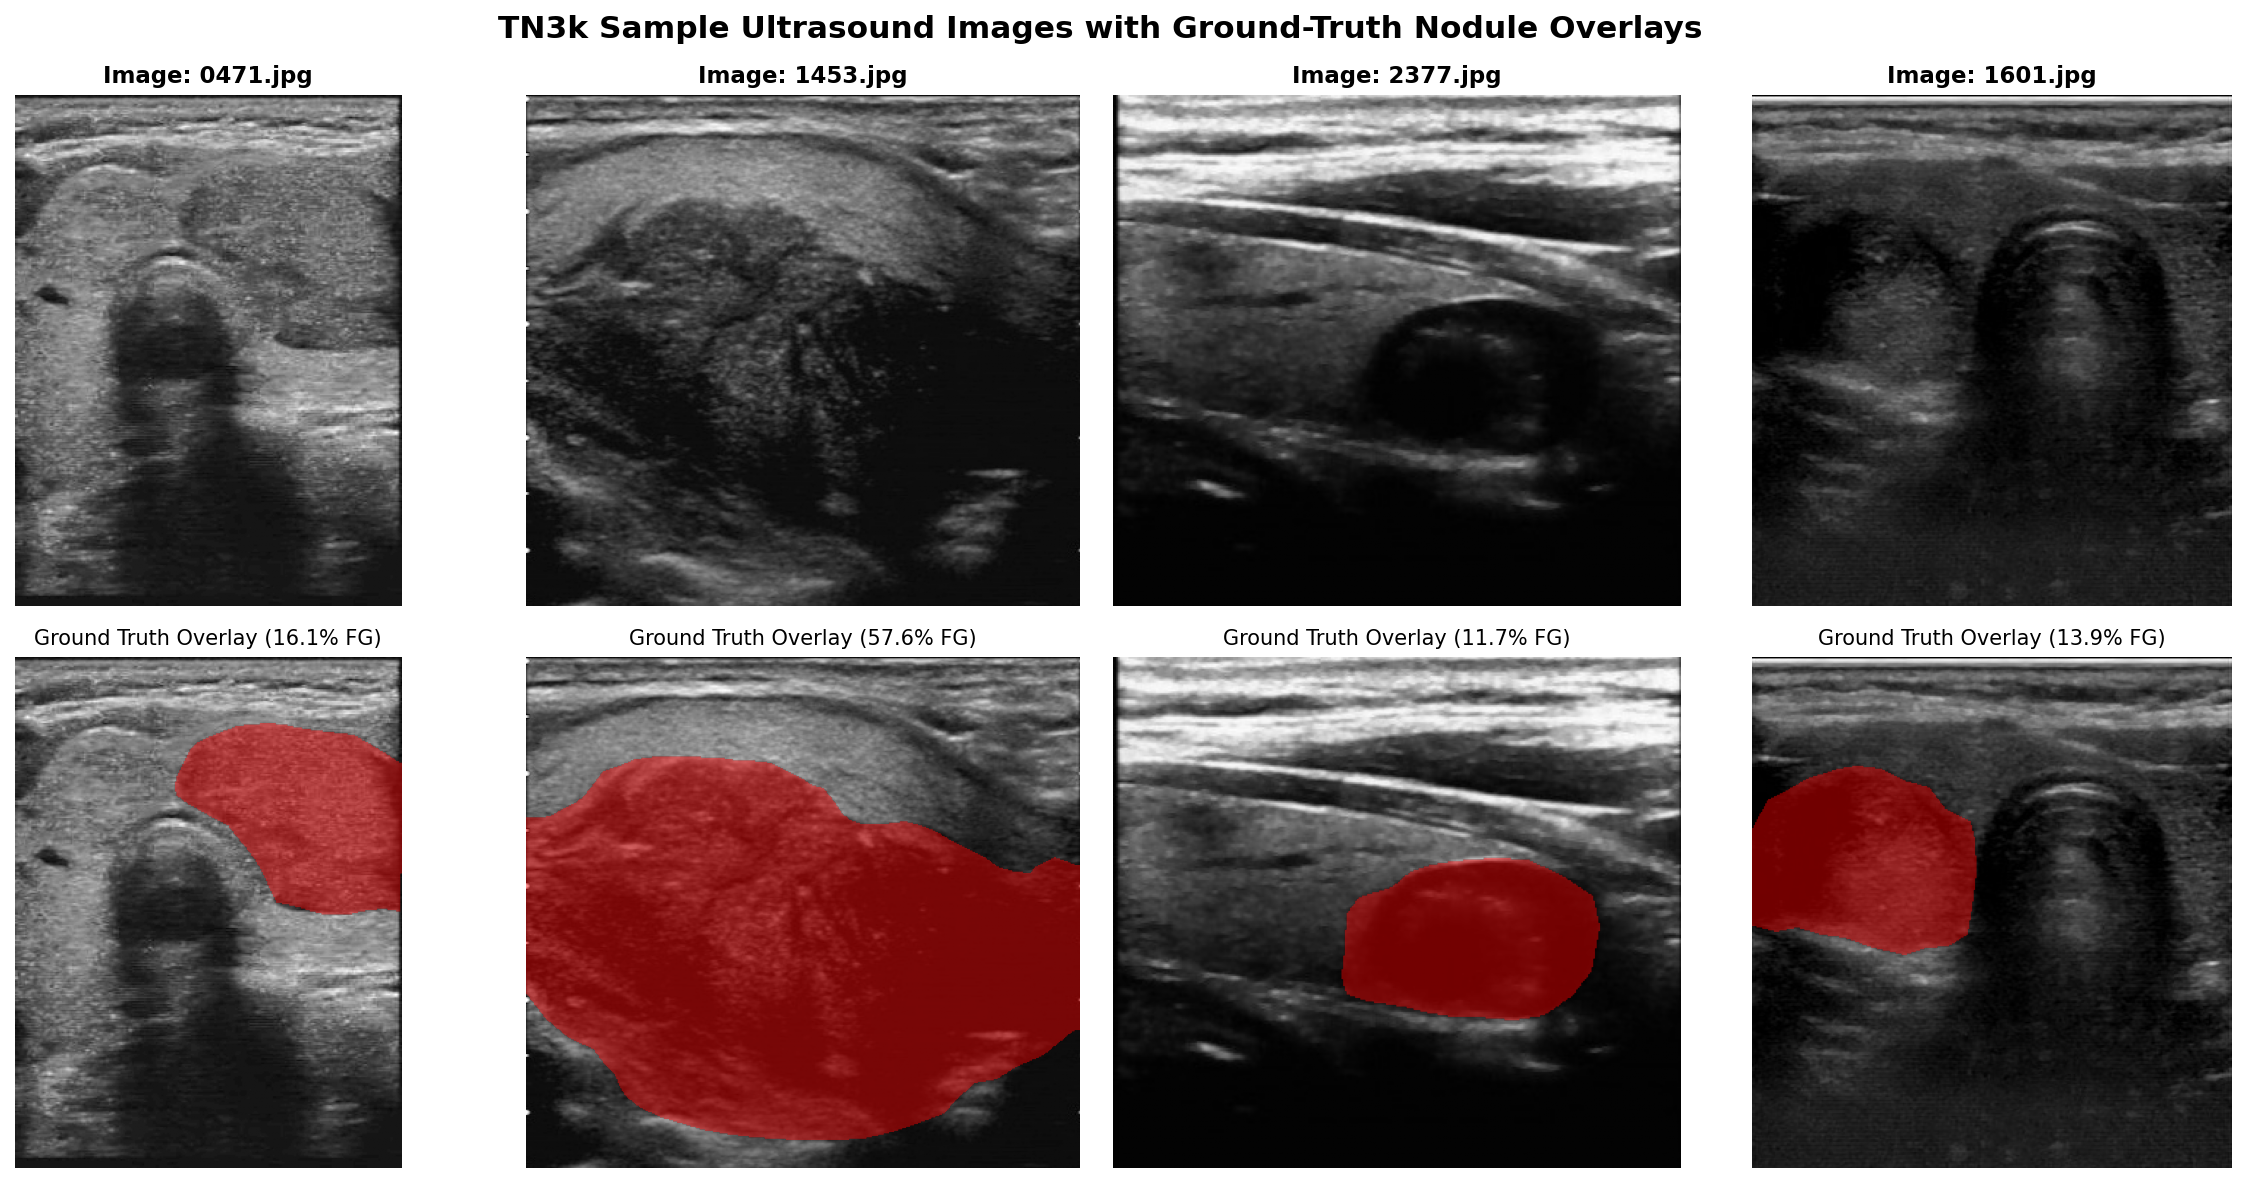

Saved visual overlay grid to: D:\DL Hackathon\thyroid-ultrasound-segmentation\outputs\eda_sample_overlays.png


In [4]:
overlay_path = output_dir / "eda_sample_overlays.png"

# Select 4 deterministic random samples from trainval
np.random.seed(42)
all_mask_names = imbalance_stats["mask_names"]
sampled_indices = np.random.choice(len(all_mask_names), size=4, replace=False)
sample_fnames = [all_mask_names[idx] for idx in sampled_indices]

fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=150)

for i, fn in enumerate(sample_fnames):
    img_p = trainval_img_dir / fn
    mask_p = trainval_mask_dir / fn
    
    img = np.array(Image.open(img_p).convert("L"))
    mask = np.array(Image.open(mask_p).convert("L")) > 127
    
    # Row 0: Original Ultrasound Image
    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"Image: {fn}", fontsize=11, fontweight="semibold")
    axes[0, i].axis("off")
    
    # Row 1: Ultrasound with Red Mask Overlay
    axes[1, i].imshow(img, cmap="gray")
    overlay = np.zeros((*img.shape, 4), dtype=np.float32)
    overlay[mask] = [1.0, 0.0, 0.0, 0.45]  # Semi-transparent red
    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f"Ground Truth Overlay ({mask.sum() / mask.size * 100:.1f}% FG)", fontsize=10)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Ultrasound Image", fontsize=12, labelpad=10)
axes[1, 0].set_ylabel("Ground Truth Overlay", fontsize=12, labelpad=10)
fig.suptitle("TN3k Sample Ultrasound Images with Ground-Truth Nodule Overlays", fontsize=15, fontweight="bold", y=0.98)

plt.tight_layout()
fig.savefig(str(overlay_path), bbox_inches="tight")
plt.show()
print(f"Saved visual overlay grid to: {overlay_path}")


Train loader batches: 143 (2303 samples)
Val loader batches:   36 (576 samples)
Test loader batches:  39 (614 samples)

[Test Batch Tensor Inspection]
Batch Image Tensor: torch.Size([16, 3, 256, 256]), dtype=torch.float32, min=-2.118, max=2.640


Batch Mask Tensor:  torch.Size([16, 1, 256, 256]), dtype=torch.float32, unique_values=[0.0, 1.0]


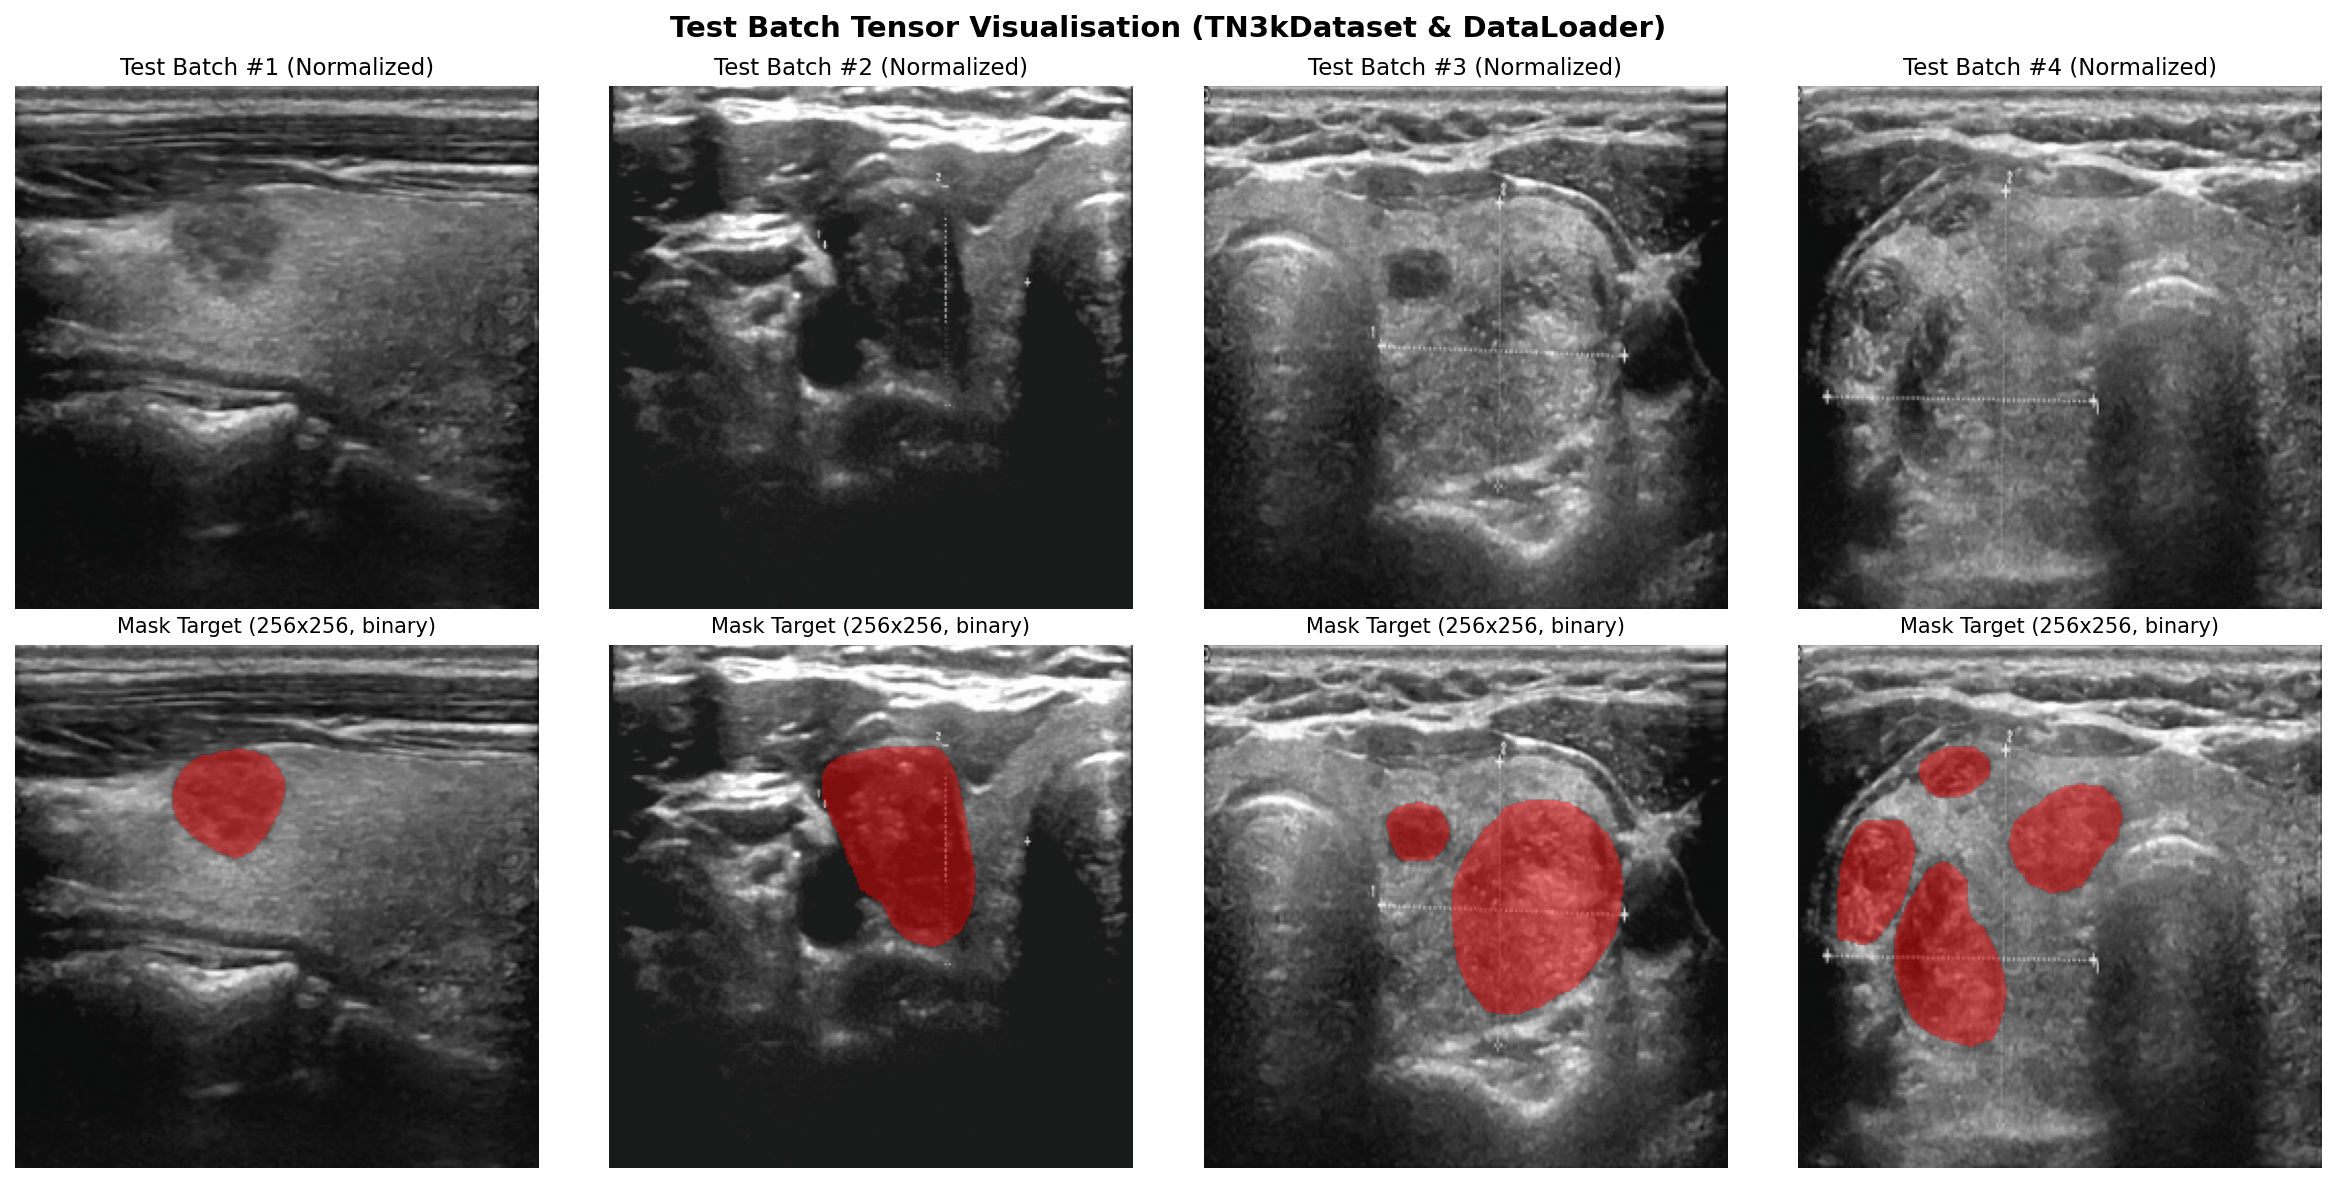

In [5]:
# Initialize TN3kDataset and loaders
train_loader, val_loader, test_loader = get_loaders(
    data_root=str(data_root),
    batch_size=16,
    num_workers=0,  # 0 workers inside interactive notebook
    img_size=256
)

print(f"Train loader batches: {len(train_loader)} ({len(train_loader.dataset)} samples)")
print(f"Val loader batches:   {len(val_loader)} ({len(val_loader.dataset)} samples)")
print(f"Test loader batches:  {len(test_loader)} ({len(test_loader.dataset)} samples)")

# Pull one test batch
test_batch_images, test_batch_masks = next(iter(test_loader))
print("\n[Test Batch Tensor Inspection]")
print(f"Batch Image Tensor: {test_batch_images.shape}, dtype={test_batch_images.dtype}, min={test_batch_images.min():.3f}, max={test_batch_images.max():.3f}")
print(f"Batch Mask Tensor:  {test_batch_masks.shape}, dtype={test_batch_masks.dtype}, unique_values={torch.unique(test_batch_masks).tolist()}")

# Visualize first 4 samples from the batch inline
fig, axes = plt.subplots(2, 4, figsize=(16, 8), dpi=150)

# Un-normalize ImageNet images for display: img * std + mean
mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)

for i in range(4):
    img_tensor = test_batch_images[i].cpu().numpy()
    mask_tensor = test_batch_masks[i, 0].cpu().numpy()
    
    # Denormalize to [0, 1]
    img_disp = np.clip(img_tensor * std + mean, 0.0, 1.0).transpose(1, 2, 0)
    
    # Batch Image
    axes[0, i].imshow(img_disp)
    axes[0, i].set_title(f"Test Batch #{i+1} (Normalized)", fontsize=11)
    axes[0, i].axis("off")
    
    # Batch Mask Overlay
    axes[1, i].imshow(img_disp)
    overlay = np.zeros((256, 256, 4), dtype=np.float32)
    overlay[mask_tensor > 0.5] = [1.0, 0.0, 0.0, 0.45]
    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f"Mask Target (256x256, binary)", fontsize=10)
    axes[1, i].axis("off")

fig.suptitle("Test Batch Tensor Visualisation (TN3kDataset & DataLoader)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()
